In [62]:
import torch
import matplotlib.pyplot as plt
from torch import nn
print("Gpu enabled: ",torch.cuda.is_available())
print("Version",torch.__version__)

Gpu enabled:  True
Version 2.11.0+cu128


In [63]:
weight = 50 # 
bias = 10000

start=500
end=2100
step=100

X = torch.arange(start,end,step, dtype=torch.float32).reshape(16,1) # area of house
X_normalized = (X - X.min()) / (X.max() - X.min())
noise = torch.randn_like(X.float()) # random noise ( because real world data is more scattered )
y = weight * X_normalized + bias + noise # monthly rent


X_normalized[:10], y[:10]


(tensor([[0.0000],
         [0.0667],
         [0.1333],
         [0.2000],
         [0.2667],
         [0.3333],
         [0.4000],
         [0.4667],
         [0.5333],
         [0.6000]]),
 tensor([[10001.9268],
         [10004.8203],
         [10007.5674],
         [10007.8945],
         [10014.0117],
         [10015.4326],
         [10019.9570],
         [10021.7285],
         [10025.9150],
         [10031.6484]]))

In [64]:
split_percentage = int(0.8* len(X_normalized))

x_train, y_train = X_normalized[:split_percentage], y[:split_percentage]
x_test, y_test = X_normalized[split_percentage:], y[split_percentage:]

len(x_train), len(y_train), len(x_test), len(y_test)
x_train, y_train

(tensor([[0.0000],
         [0.0667],
         [0.1333],
         [0.2000],
         [0.2667],
         [0.3333],
         [0.4000],
         [0.4667],
         [0.5333],
         [0.6000],
         [0.6667],
         [0.7333]]),
 tensor([[10001.9268],
         [10004.8203],
         [10007.5674],
         [10007.8945],
         [10014.0117],
         [10015.4326],
         [10019.9570],
         [10021.7285],
         [10025.9150],
         [10031.6484],
         [10032.9404],
         [10035.2637]]))

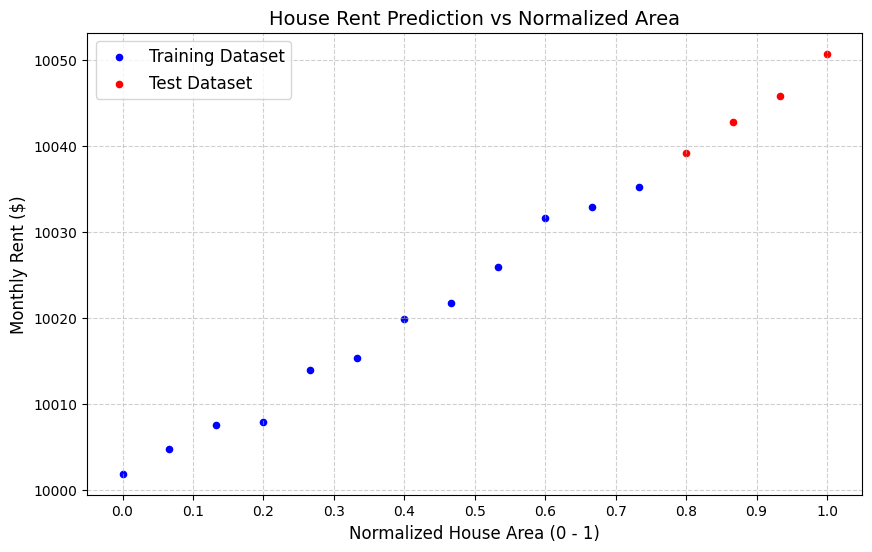

In [65]:
def plot_graph(x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test, predictions=None):
    plt.figure(figsize=(10, 6))
    
    # Format X-axis ticks (since X is normalized 0-1)
    plt.xticks(torch.arange(0, 1.1, 0.1))
    
    # Convert PyTorch tensors to CPU/numpy for plotting
    def to_np(tensor):
        return tensor.detach().cpu().numpy() if isinstance(tensor, torch.Tensor) else tensor

    # Plot datasets
    plt.scatter(to_np(x_train), to_np(y_train), s=20, c="b", label="Training Dataset")
    plt.scatter(to_np(x_test), to_np(y_test), s=20, c="r", label="Test Dataset")
    
    if predictions is not None:
        plt.scatter(to_np(x_test), to_np(predictions), s=25, c="g", label="Model Predictions")
        
    plt.title("House Rent Prediction vs Normalized Area", fontsize=14)
    plt.xlabel("Normalized House Area (0 - 1)", fontsize=12)
    plt.ylabel("Monthly Rent ($)", fontsize=12)
    plt.legend(prop={"size": 12})
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

plot_graph()


In [66]:
class HouseRentModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))
        
    def forward(self, x:torch.Tensor):
        return self.weights * x + self.bias
    

model = HouseRentModel()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.4617]), 'bias': tensor([0.2674])})
[Parameter containing:
tensor([0.4617], requires_grad=True), Parameter containing:
tensor([0.2674], requires_grad=True)]


tensor([[0.6367],
        [0.6675],
        [0.6982],
        [0.7290]])


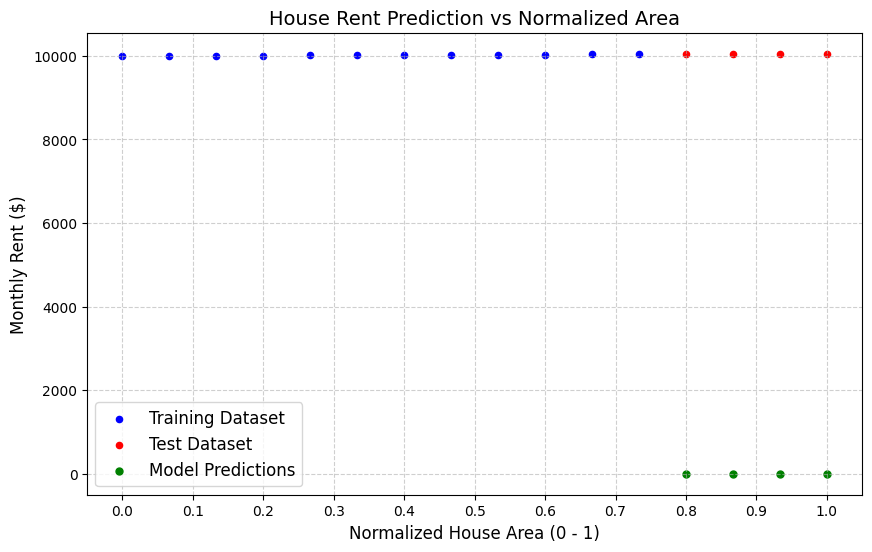

In [67]:
torch.manual_seed(42)

with torch.inference_mode():
    model_predictions = model(x_test)
    print(model_predictions)
    plot_graph(predictions=model_predictions)

In [68]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [69]:
epochs = 35000

for epoch in range(epochs):
    model.train()
    
    y_pred = model(x_train)
    loss = loss_fn(y_pred,y_train)
    
    optimizer.zero_grad()
    loss.backward()
    
    optimizer.step()
    
    if epoch % 5000 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")    

Epoch: 0 | Loss: 100356888.0
Epoch: 5000 | Loss: 1.4307775497436523
Epoch: 10000 | Loss: 1.4308465719223022
Epoch: 15000 | Loss: 1.4308465719223022
Epoch: 20000 | Loss: 1.4307775497436523
Epoch: 25000 | Loss: 1.4308465719223022
Epoch: 30000 | Loss: 1.4308465719223022


OrderedDict({'weights': tensor([47.5402]), 'bias': tensor([10000.8252])})
tensor([[10038.8574],
        [10042.0264],
        [10045.1963],
        [10048.3652]])


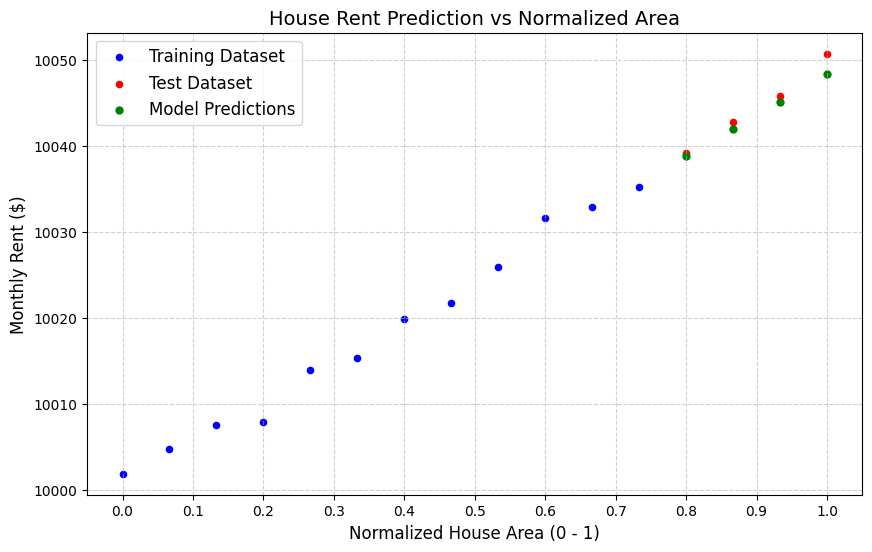

In [70]:
print(model.state_dict())

with torch.inference_mode():
    y_preds = model(x_test)

print(y_preds)
plot_graph(predictions=y_preds)